# Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

base_path = Path("Data")
df = pd.read_excel(base_path / "SENTIMENT.xlsx", sheet_name = 'DATA')
df['yearmo'] = pd.to_datetime(df['yearmo'], format = '%Y%m')
df.index = df['yearmo']
df = df.drop(columns = ['yearmo'])
our_df = df[(df.index >= '1984-01-01') & (df.index <= '2022-12-01')].copy()
yearend_df = our_df[our_df.index.month == 12].copy()

# Figure 1
- Comparing the 6 key proxy variables before and after removing macroeconomic influences. 
- Data is sourced from the author's website. ('turnover' has been excluded, according to the author's recommendation)

## Macroeconomic Variables

In [2]:
# growth in industrial production
indpro = df['indpro']
indpro_growth = np.log(indpro) - np.log(indpro.shift(12))
indpro_growth = indpro_growth[(indpro_growth.index >= '1984-01-01') & (indpro_growth.index <= '2022-12-01')]
indpro_annual = indpro_growth[indpro_growth.index.month == 12]
indpro_annual.index = indpro_annual.index.year

# growth in durables/ nondurables/ services consumption
consdur = df['consdur']
consnon = df['consnon']
consserv = df['consserv']
cpi = df['cpi']

r_consdur = consdur/cpi
r_consnon = consnon/cpi
r_consserv = consserv/cpi

consdur_growth = np.log(r_consdur) - np.log(r_consdur.shift(12))
consdur_growth = consdur_growth[(consdur_growth.index >= '1984-01-01') & (consdur_growth.index <= '2022-12-01')]
consdur_annual = consdur_growth[consdur_growth.index.month == 12]
consdur_annual.index = consdur_annual.index.year

consnon_growth = np.log(r_consnon) - np.log(r_consnon.shift(12))
consnon_growth = consnon_growth[(consnon_growth.index >= '1984-01-01') & (consnon_growth.index <= '2022-12-01')]
consnon_annual = consnon_growth[consnon_growth.index.month == 12]
consnon_annual.index = consnon_annual.index.year

consserv_growth = np.log(r_consserv) - np.log(r_consserv.shift(12))
consserv_growth = consserv_growth[(consserv_growth.index >= '1984-01-01') & (consserv_growth.index <= '2022-12-01')]
consserv_annual = consserv_growth[consserv_growth.index.month == 12]
consserv_annual.index = consserv_annual.index.year

# growth of employment
employ = df['employ']
employ_growth = np.log(employ) - np.log(employ.shift(12))
employ_growth = employ_growth[(employ_growth.index >= '1984-01-01') & (employ_growth.index <= '2022-12-01')]
employ_annual = employ_growth[employ_growth.index.month == 12]
employ_annual.index = employ_annual.index.year

# dummy for NBER recession
recess = our_df['recess']
recess_annual = recess.groupby(recess.index.year).max()

## Regress Each of 6 Proxies on Macroeconomic Variables

In [3]:
import statsmodels.api as sm

# investor sentiment proxies
cefd = yearend_df['cefd']
cefd.index = cefd.index.year

nipo = our_df['nipo']
nipo_annual = nipo.groupby(nipo.index.year).sum()

ripo = yearend_df['ripo']
ripo.index = ripo.index.year
ripo = ripo.shift(1)

s = yearend_df['s']*100
s.index = s.index.year

pdnd = yearend_df['pdnd']
pdnd.index = pdnd.index.year
pdnd = pdnd.shift(1)

proxies = {'cefd': cefd, 'nipo': nipo_annual, 'ripo': ripo, 's': s, 'pdnd': pdnd}

# macro to dataframe
macro_df = pd.concat([indpro_annual, consdur_annual, consnon_annual, consserv_annual, employ_annual, recess_annual], axis = 1)
macro_df.columns = ['indpro_growth', 'consdur_growth', 'consnon_growth', 'consserv_growth', 'employ_growth', 'recess']

# regression to get residuals
residuals = {}
for name, series in proxies.items():
    reg = pd.concat([series, macro_df], axis = 1).dropna()
    y = reg[name]
    x = sm.add_constant(reg[macro_df.columns])
    residuals[name] = sm.OLS(y, x).fit().resid

residuals = pd.DataFrame(residuals)
residuals

,cefd,nipo,ripo,s,pdnd
yearmo,,,,,
1984,-5.170391,-48.731016,NaN,4.769328,NaN
1985,-1.156329,29.873985,-19.051266,4.497443,-4.982689
1986,-3.415980,308.461202,-9.972923,2.097828,0.958458
1987,3.656797,272.772936,-5.776240,3.373970,-4.384763
1988,8.212528,-272.123707,NaN,-1.782685,4.029879
...,...,...,...,...,...
2018,0.183270,-2.447819,9.326128,-3.025614,5.109813
2019,0.103170,-46.747144,-34.228231,-1.034865,3.545390
2020,0.112648,290.279207,21.710865,0.167968,-10.677863


## Closed-end fund discount %
- year-end, equal-weighted average discount 

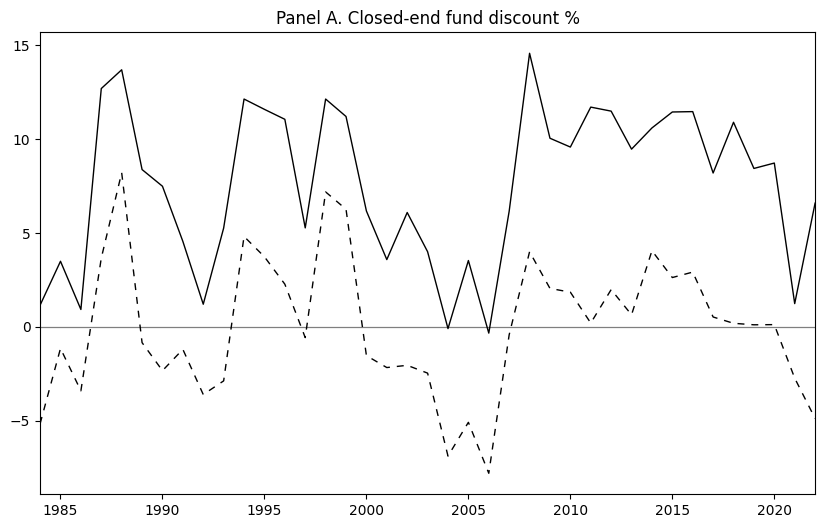

In [4]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.plot(cefd.index, cefd.values, color = 'black', linewidth = 1)
plt.plot(residuals.index, residuals['cefd'], color = 'black', linestyle = (0, (5, 5)), linewidth = 1)
plt.title('Panel A. Closed-end fund discount %')
plt.axhline(0, color = 'black', linewidth = 0.9, alpha = 0.5)
ax.set_xlim([cefd.index.min(), cefd.index.max()])
plt.show()

## Numbers of IPOs
- annual numbers (sum of monthly data)

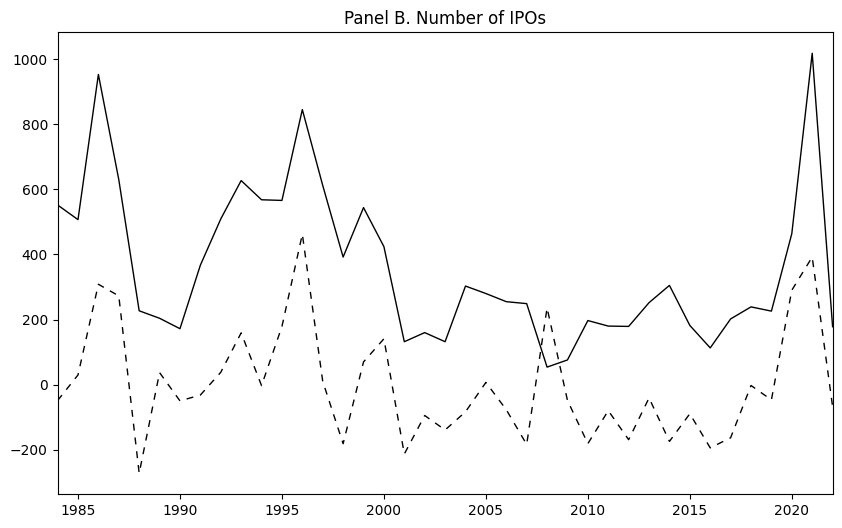

In [5]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.plot(nipo_annual.index, nipo_annual.values, color = 'black', linewidth = 1)
plt.plot(residuals.index, residuals['nipo'], color = 'black', linestyle = (0, (5, 5)), linewidth = 1)
plt.title('Panel B. Number of IPOs')
ax.set_xlim([nipo_annual.index.min(), nipo_annual.index.max()])
plt.show()

## Average first-day return %
- NIPO-weighted average over the prior twelve months to smooth noise, and the annual proxy is taken from the year-end observation
- Contain missing values, we retain the original series without imputation

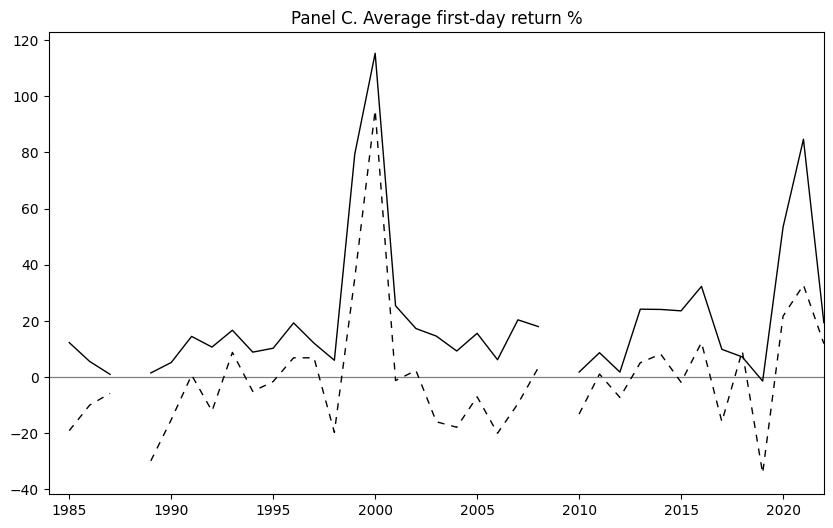

In [6]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.plot(ripo.index, ripo.values, color = 'black', linewidth = 1)
plt.plot(residuals.index, residuals['ripo'], color = 'black', linestyle = (0, (5, 5)), linewidth = 1)
plt.title('Panel C. Average first-day return %')
plt.axhline(0, color = 'black', linewidth = 0.9, alpha = 0.5)
ax.set_xlim([ripo.index.min(), ripo.index.max()])
plt.show()

## Equity share in new issues %
- use the year end value
- We rescale the series by multiplying it by 100 for consistency with the paper (percentage term)

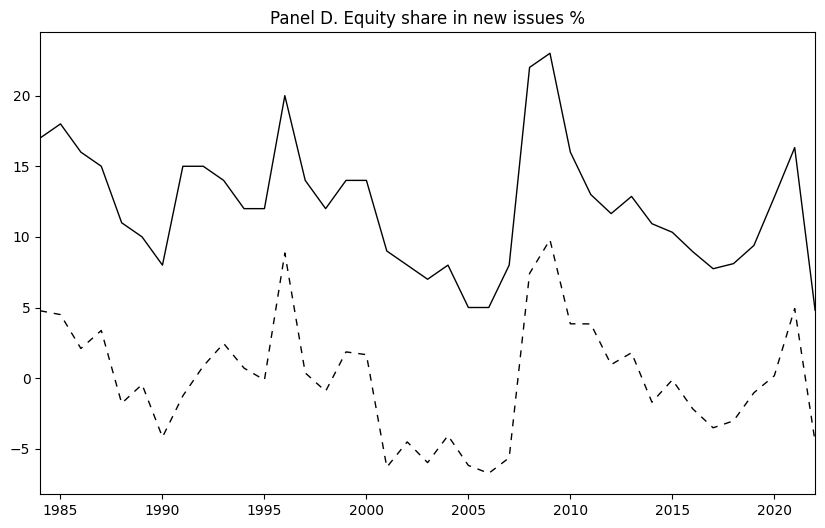

In [7]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.plot(s.index, s.values, color = 'black', linewidth = 1)
plt.plot(residuals.index, residuals['s'], color = 'black', linestyle = (0, (5, 5)), linewidth = 1)
plt.title('Panel D. Equity share in new issues %')
ax.set_xlim([s.index.min(), s.index.max()])
plt.show()

## Dividend premium
- use the year end value
- log ratio*100

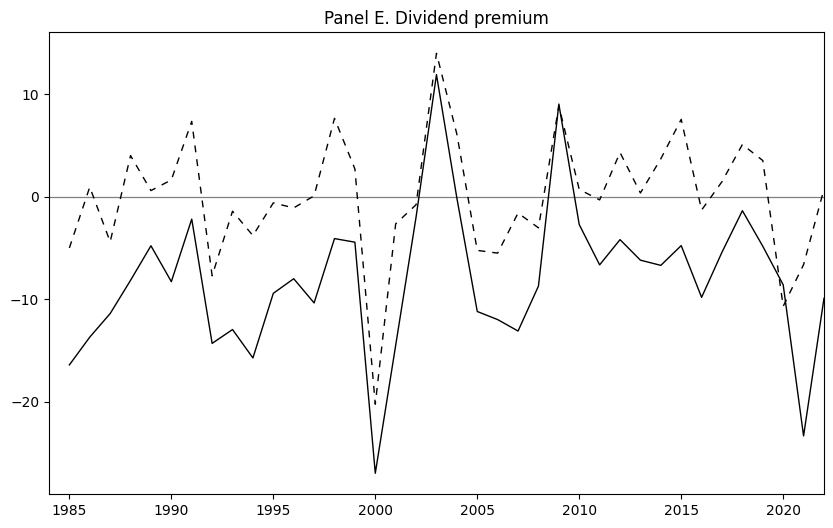

In [8]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.plot(pdnd.index, pdnd.values, color = 'black', linewidth = 1)
plt.plot(residuals.index, residuals['pdnd'], color = 'black', linestyle = (0, (5, 5)), linewidth = 1)
plt.title('Panel E. Dividend premium')
plt.axhline(0, color = 'black', linewidth = 0.9, alpha = 0.5)
ax.set_xlim([pdnd.index.min(), pdnd.index.max()])
plt.show()

## Sentiment index (SENTIMENT)
- use the year end value
- The solid (dashed) line in the panel is a first principal component index of the five raw (orthogonalized) measures

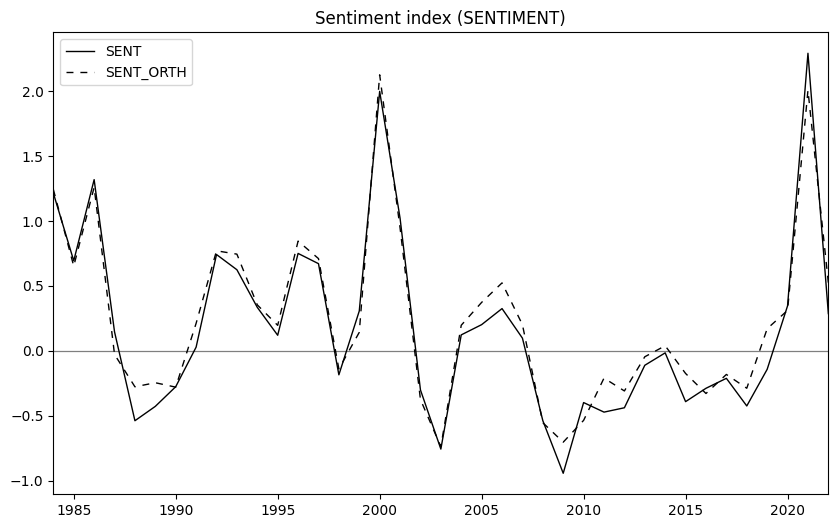

In [9]:
sent = yearend_df['SENT']
sent.index = sent.index.year

sent_orth = yearend_df['SENT_ORTH']
sent_orth.index = sent_orth.index.year

fig, ax = plt.subplots(figsize = (10, 6))
plt.plot(sent.index, sent.values, color = 'black', linewidth = 1, label = 'SENT')
plt.plot(sent_orth.index, sent_orth.values, color = 'black', linestyle = (0, (5, 5)), linewidth = 1, label = 'SENT_ORTH')
plt.title('Sentiment index (SENTIMENT)')
plt.axhline(0, color = 'black', linewidth = 0.9, alpha = 0.5)
ax.set_xlim([sent.index.min(), sent.index.max()])
plt.legend()
plt.show()

# Table 1
- Left: Descriptive statistics of the 5 sentiment proxies
- Right: Correlation matrix
- Top/Bottom: Comparison before and after removing macroeconomic influences (orthogonalization).

## Raw Data

In [10]:
# describe statistics
curr_lag = pd.DataFrame({
    'CEFDt': cefd,
    'NIPOt': nipo_annual,
    'RIPOt_1': ripo, 
    'St': s, 
    'PDNDt_1': pdnd})

describe = curr_lag.agg(['mean', 'std', 'min', 'max']).T.round(2)

# Correlation with sent, sent_orth
corr_sentA = curr_lag.corrwith(sent).round(2)
corr_sent_orthA = curr_lag.corrwith(sent_orth).round(2)

# Correlation with Sentiment component
corr_A = curr_lag.corr().round(2)

for i in range(corr_A.shape[0]):
    for j in range(corr_A.shape[1]): 
        if j > i:
            corr_A.iloc[i, j] = ""

panelA = pd.concat([describe, corr_sentA, corr_sent_orthA, corr_A], axis = 1)
panelA.columns = ['Mean', 'SD', 'Min', 'Max', 'SENTIMENT', 'SENTIMENT_ORTH', 'CEFD', 'NIPO', 'RIPO', 'S', 'PDND']

C:\Users\User\AppData\Local\Temp\ipykernel_9740\2813402111.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  corr_A.iloc[i, j] = ""
C:\Users\User\AppData\Local\Temp\ipykernel_9740\2813402111.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  corr_A.iloc[i, j] = ""
C:\Users\User\AppData\Local\Temp\ipykernel_9740\2813402111.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  corr_A.iloc[i, j] = ""
C:\Users\User\AppData\Local\Temp\ipykernel_9740\2813402111.py:21: F

## Controlling for Macroeconomic Conditions

In [11]:
# describe statistics
curr_lag_orth = pd.DataFrame({
    'CEFD_ortht': residuals['cefd'], 
    'NIPO_ortht': residuals['nipo'], 
    'RIPO_ortht_1': residuals['ripo'], 
    'S_ortht': residuals['s'], 
    'PDND_ortht_1': residuals['pdnd']})

describe_orth = curr_lag_orth.agg(['mean', 'std', 'min', 'max']).T.round(2)

# Correlation with sent, sent_orth
corr_sentB = curr_lag_orth.corrwith(sent).round(2)
corr_sent_orthB = curr_lag_orth.corrwith(sent_orth).round(2)

# Correlation with Sentiment component
corr_B = curr_lag_orth.corr().round(2)

for i in range(corr_B.shape[0]): 
    for j in range(corr_B.shape[1]):
        if j > i:
            corr_B.iloc[i, j] = ""

panelB = pd.concat([describe_orth, corr_sentB, corr_sent_orthB, corr_B], axis = 1)
panelB.columns = ['Mean', 'SD', 'Min', 'Max', 'SENTIMENT', 'SENTIMENT_ORTH', 'CEFD', 'NIPO', 'RIPO', 'S', 'PDND']

C:\Users\User\AppData\Local\Temp\ipykernel_9740\785750069.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  corr_B.iloc[i, j] = ""
C:\Users\User\AppData\Local\Temp\ipykernel_9740\785750069.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  corr_B.iloc[i, j] = ""
C:\Users\User\AppData\Local\Temp\ipykernel_9740\785750069.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  corr_B.iloc[i, j] = ""
C:\Users\User\AppData\Local\Temp\ipykernel_9740\785750069.py:21: Futur

## Merge

In [12]:
def add_panel_title(df, title):
    empty_row = pd.DataFrame([[""]*df.shape[1]], columns = df.columns, index = [title])
    return pd.concat([empty_row, df], axis = 0)

title_panelA = add_panel_title(panelA, "Panel A: Raw Data")
title_panelB = add_panel_title(panelB, "Panel B: Controlling for Macroeconomic Conditions")

table1 = pd.concat([title_panelA, title_panelB], axis = 0)
table1

,Mean,SD,Min,Max,SENTIMENT,SENTIMENT_ORTH,CEFD,NIPO,RIPO,S,PDND
Panel A: Raw Data,,,,,,,,,,,
CEFDt,7.59,4.21,-0.34,14.58,-0.56,-0.57,1.0,,,,
NIPOt,360.9,238.53,54.0,1018.0,0.75,0.7,-0.28,1.0,,,
RIPOt_1,20.42,24.96,-1.4,115.3,0.62,0.58,-0.08,0.28,1.0,,
St,12.18,4.43,4.81,23.0,0.21,0.17,0.18,0.41,0.19,1.0,
PDNDt_1,-8.05,7.21,-26.97,11.93,-0.81,-0.81,0.23,-0.51,-0.48,-0.08,1.0
Panel B: Controlling for Macroeconomic Conditions,,,,,,,,,,,
CEFD_ortht,-0.0,3.72,-7.81,8.21,-0.38,-0.42,1.0,,,,
NIPO_ortht,-0.0,175.97,-272.12,462.26,0.53,0.49,-0.08,1.0,,,
RIPO_ortht_1,-0.0,22.31,-34.23,95.05,0.55,0.54,0.1,0.35,1.0,,


# Table 2

## Read Data

In [13]:
def read_monthly_portfolios(characteristics) -> pd.DataFrame:
    df = characteristics.copy()
    df['yearmo'] = pd.to_datetime(df['yearmo'], format = '%Y%m')
    df = df.set_index('yearmo').sort_index()
    df = df.replace([-99.99, -999, -99.990, -999.0], np.nan)
    df = df.apply(pd.to_numeric, errors = 'coerce')
    return df

## Group By Sentiment and Calculate Average Portfolios Return

In [14]:
def table2_characteristic(monthly: pd.DataFrame, sentiment: pd.Series) -> pd.DataFrame:

    sent = sentiment.copy()
    sent.index = sent.index.astype(int)

    sent_for_month = pd.Series(monthly.index.year - 1, index = monthly.index).map(sent)

    pos_year = sent_for_month > 0
    neg_year = sent_for_month < 0

    output = pd.DataFrame({
        'Positive': monthly.loc[pos_year].mean(), 
        'Negative': monthly.loc[neg_year].mean()
    })
    output['Difference'] = output['Positive'] - output['Negative']
    return output.round(2)

## Characteristics
- volatility --> risk
- profitability is used as a proxy for E/BE
- Investment portfolios are used as a proxy for EF/A
- DY is used as a proxy for D/BE
- NI is used as a proxy for GS ...high NI is typically associated with growth stocks  
  
**additional chraracteristc**
- AC (accruals): High/Low AC indicates higher cash flow uncertainty; may capture U-shaped patterns (hard to value & arbitrage)

In [15]:
from pathlib import Path
base_path = Path("Data")

# size
port_me = pd.read_excel(base_path / "ME.xlsx", sheet_name = 'our_data')
me_monthly = read_monthly_portfolios(port_me)
table2_me = table2_characteristic(me_monthly, sent)
table2_me = table2_me.T

# risk
port_vol = pd.read_excel(base_path / "volatility.xlsx", sheet_name = 'our_data')
vol_monthly = read_monthly_portfolios(port_vol)
table2_vol = table2_characteristic(vol_monthly, sent)
table2_vol = table2_vol.T

# E/BE
port_prof = pd.read_excel(base_path / "profitability.xlsx", sheet_name = 'our_data')
prof_monthly = read_monthly_portfolios(port_prof)
table2_prof = table2_characteristic(prof_monthly, sent)
table2_prof = table2_prof.T

# D/BE
port_dy = pd.read_excel(base_path / "DY.xlsx", sheet_name = 'our_data')
dy_monthly = read_monthly_portfolios(port_dy)
table2_dy = table2_characteristic(dy_monthly, sent)
table2_dy = table2_dy.T

# BE/ME
port_beme = pd.read_excel(base_path / "BEME.xlsx", sheet_name = 'our_data')
beme_monthly = read_monthly_portfolios(port_beme)
table2_beme = table2_characteristic(beme_monthly, sent)
table2_beme = table2_beme.T

# EF/A
port_inv = pd.read_excel(base_path / "INV.xlsx", sheet_name = 'our_data')
inv_monthly = read_monthly_portfolios(port_inv)
table2_inv = table2_characteristic(inv_monthly, sent)
table2_inv = table2_inv.T

# GS
port_ni = pd.read_excel(base_path / "NI.xlsx", sheet_name = 'our_data')
ni_monthly = read_monthly_portfolios(port_ni)
table2_ni = table2_characteristic(ni_monthly, sent)
table2_ni = table2_ni.T

# AC
port_ac = pd.read_excel(base_path / "AC.xlsx", sheet_name = 'our_data')
ac_monthly = read_monthly_portfolios(port_ac)
table2_ac = table2_characteristic(ac_monthly, sent)
table2_ac = table2_ac.T

# adding comparisons columns
table2 = pd.concat([table2_me, table2_vol, table2_prof, table2_dy, table2_beme, table2_inv, table2_ni, table2_ac], axis = 0)
table2["10-1"] = table2["decile 10"] - table2["decile 1"]
table2["10-5"] = table2["decile 10"] - table2["decile 5"]
table2["5-1"] = table2["decile 5"] - table2["decile 1"]
table2 = table2.round(2)

# adding characteristics names
characteristics_list = ['ME', 'VOL', 'E/BE', 'D/BE', 'BE/ME', 'EF/A', 'GS', 'AC']
table2 = table2.reset_index().rename(columns = {'index': ' '})
table2.insert(0, 'Characteristic', '')

for i, char in enumerate(characteristics_list): 
    table2.iloc[i*3 + 1, 0] = char

table2 = table2.set_index('Characteristic')
table2

,,decile 1,decile 2,decile 3,decile 4,decile 5,decile 6,decile 7,decile 8,decile 9,decile 10,10-1,10-5,5-1
Characteristic,,,,,,,,,,,,,,
,Positive,0.51,0.48,0.57,0.51,0.55,0.64,0.64,0.54,0.67,0.62,0.11,0.07,0.04
ME,Negative,1.75,1.46,1.61,1.52,1.62,1.55,1.59,1.64,1.53,1.40,-0.35,-0.22,-0.13
,Difference,-1.23,-0.97,-1.04,-1.00,-1.07,-0.92,-0.95,-1.10,-0.86,-0.77,0.46,0.30,0.16
,Positive,1.00,1.08,1.08,1.02,1.04,0.99,0.98,0.74,0.45,-0.27,-1.27,-1.31,0.04
VOL,Negative,1.11,1.27,1.34,1.35,1.44,1.52,1.70,1.83,1.94,1.84,0.73,0.40,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GS,Negative,1.63,1.65,1.79,1.73,1.84,1.86,1.90,1.80,1.67,1.42,-0.21,-0.42,0.21
,Difference,-0.82,-0.72,-0.79,-0.82,-1.00,-1.05,-1.36,-1.54,-1.73,-2.09,-1.27,-1.09,-0.18
,Positive,0.43,0.74,0.70,0.66,0.60,0.60,0.59,0.77,0.51,-0.10,-0.53,-0.70,0.17


# Figure 2
- X-axis: decile 1-10, Y-axis: average monthly return
- Solid bars: average monthly return in high sentiment periods
- clear bars: average monthly return in low sentiment periods
- solid lines: the difference in both periods
- dashed lines: the average in both periods

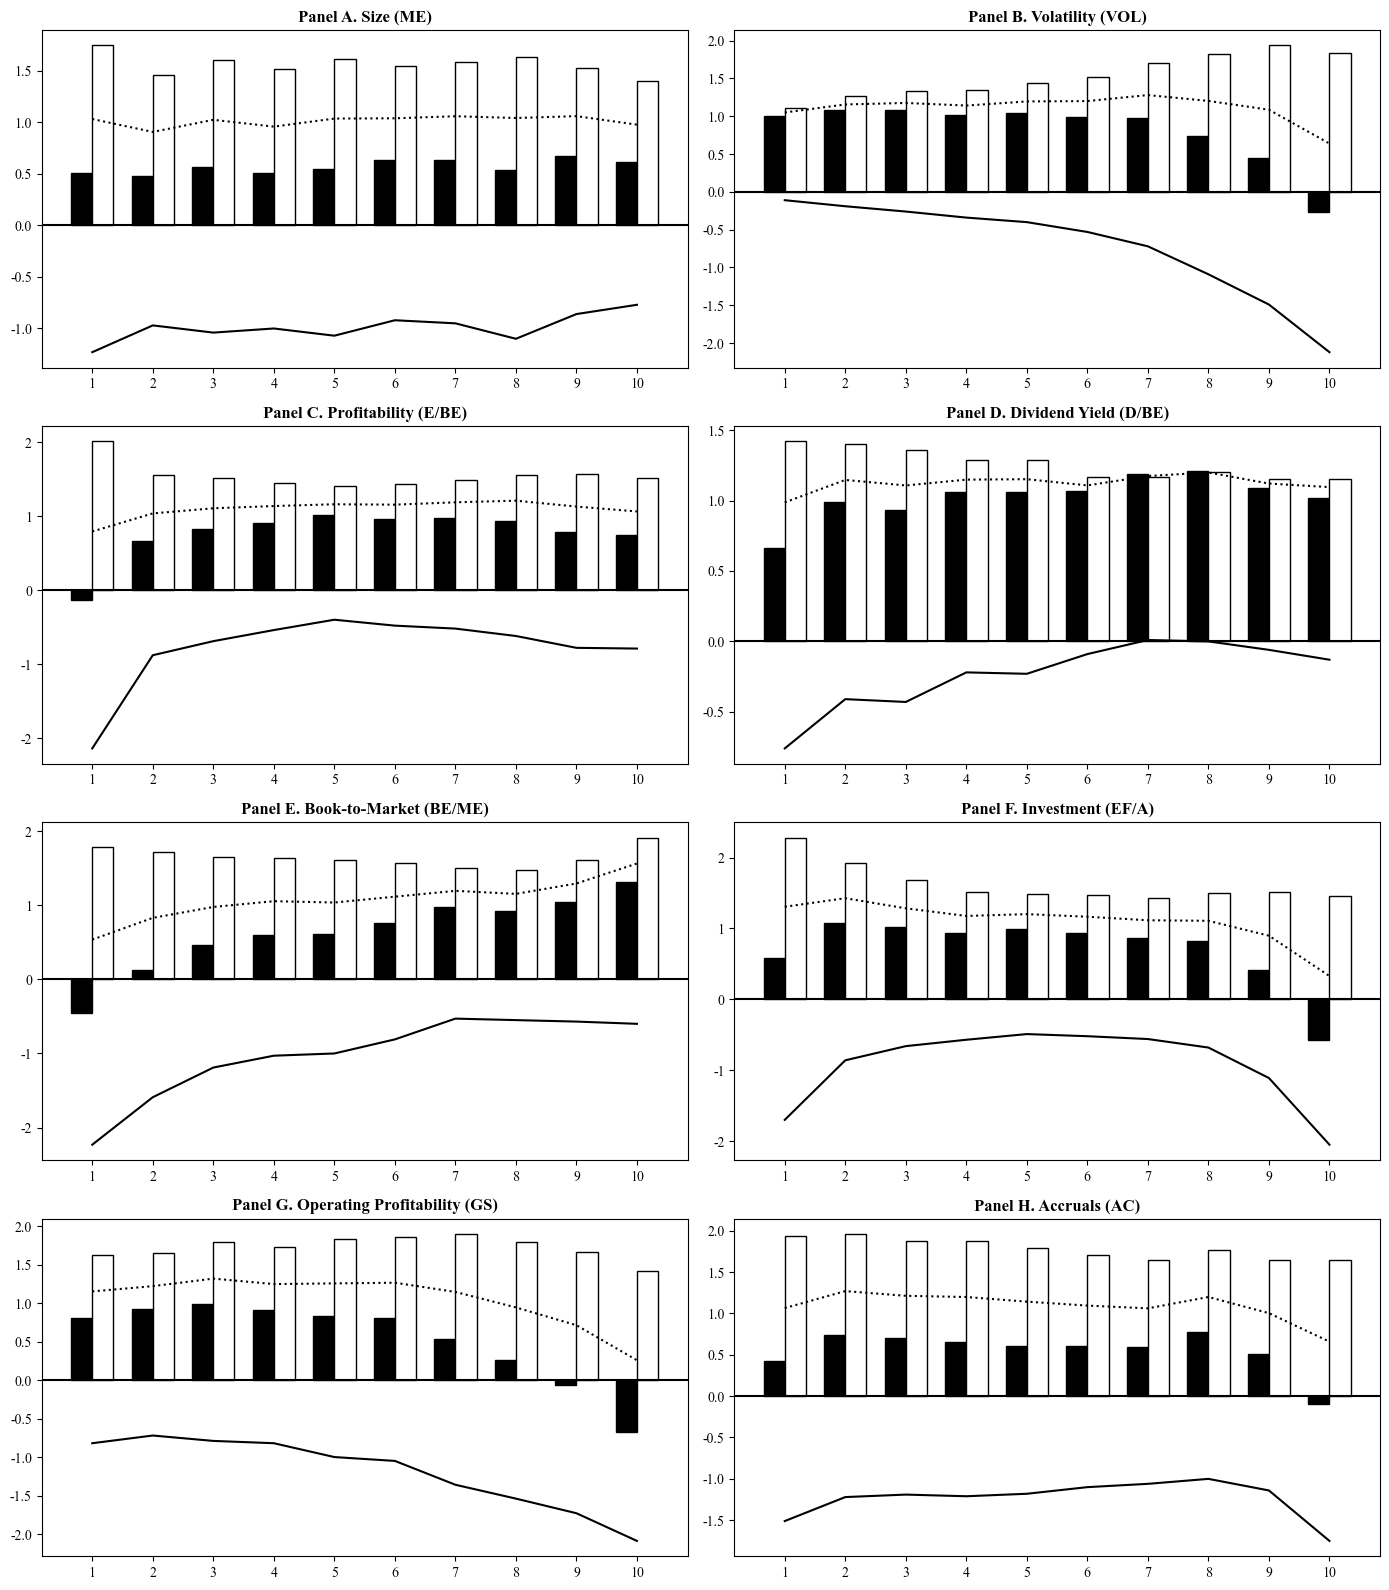

In [16]:
import matplotlib.pyplot as plt

# setting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# data, corresponding list
plot_data_list = [
    ('Panel A. Size (ME)', table2_me, me_monthly),
    ('Panel B. Volatility (VOL)', table2_vol, vol_monthly),
    ('Panel C. Profitability (E/BE)', table2_prof, prof_monthly),
    ('Panel D. Dividend Yield (D/BE)', table2_dy, dy_monthly),
    ('Panel E. Book-to-Market (BE/ME)', table2_beme, beme_monthly),
    ('Panel F. Investment (EF/A)', table2_inv, inv_monthly),
    ('Panel G. Operating Profitability (GS)', table2_ni, ni_monthly),
    ('Panel H. Accruals (AC)', table2_ac, ac_monthly)
]

# plot
fig, axes = plt.subplots(4, 2, figsize = (14, 16))
axes = axes.flatten()
deciles = np.arange(1, 11)
width = 0.35

for i, (title, df_table2, df_monthly) in enumerate(plot_data_list):
    ax = axes[i]

    df_table2.columns = range(1, 11)
    df_monthly.columns = range(1, 11)

    pos_sent = df_table2.loc['Positive']
    neg_sent = df_table2.loc['Negative']
    diff_line = df_table2.loc['Difference']
    avg_line = df_monthly.mean()

    ax.bar(deciles - width/2, pos_sent, width = width, label = 'Positive Sentiment', color = 'black', edgecolor = 'black')
    ax.bar(deciles + width/2, neg_sent, width = width, label = 'Negative Sentiment', color = 'white', edgecolor = 'black', hatch = '')

    ax.plot(deciles, diff_line, color = 'black', linestyle = '-', label = 'Difference')
    ax.plot(deciles, avg_line, color = 'black', linestyle = ':', label = 'Average')

    ax.set_title(title, fontsize = 12, fontweight = 'bold')
    ax.set_xticks(deciles)
    ax.set_xticklabels(deciles)
    ax.axhline(0, color = 'black')

plt.tight_layout()
plt.show()

# Table 3
- $$R_{X_{it=High},t} - R_{X_{it=Low},t} = c + d SENTIMENT_{t-1} + \beta RMRF_t + s SMB_t + h HML_t + m UMD_t + u_t $$
- the monthly returns from January through December of t are regressed on the sentiment index that prevailed at the end of the prior year
- dependent variable: monthly return on a long–short portfolio (long on stocks with high values of characteristic, short on stocks with low values) 

## Data
- due to data limitations, some Portfolios (High/Med/Low) are sorted by NYSE decile breakpoints (30/40/30), while some are (20/60/20)
- (30/40/30): profitability(earn), BEME, INV(E/FA), DY
- (20/60/20): volatility, NI(GS), AC  
while med60 = (Qnt2+Qnt3+Qnt4)/3

### Characteristics

In [17]:
def read_table3_charac(df: pd.DataFrame) -> pd.DataFrame:
    df = df.replace([-99.99, -999, -99.990, -999.0], np.nan)
    df = df.apply(pd.to_numeric, errors = 'coerce')
    out = df.copy()
    out['yearmo'] = pd.to_datetime(out['yearmo'], format = '%Y%m')
    out = out.set_index('yearmo').sort_index()
    return out

# Volatility
high_low_vol = pd.read_excel(base_path / "volatility.xlsx", sheet_name = 'high_low')
high_low_vol = read_table3_charac(high_low_vol)

# Earnings
high_low_earn = pd.read_excel(base_path / "profitability.xlsx", sheet_name = 'high_low')
high_low_earn = read_table3_charac(high_low_earn)

# Dividends
high_low_dy = pd.read_excel(base_path / "DY.xlsx", sheet_name = 'high_low')
high_low_dy = read_table3_charac(high_low_dy)

# BE/ME
high_low_beme = pd.read_excel(base_path / "BEME.xlsx", sheet_name = 'high_low')
high_low_beme = read_table3_charac(high_low_beme)

# EF/A
high_low_efa = pd.read_excel(base_path / "INV.xlsx", sheet_name = 'high_low')
high_low_efa = read_table3_charac(high_low_efa)

# GS
high_low_gs = pd.read_excel(base_path / "NI.xlsx", sheet_name = 'high_low')
high_low_gs = read_table3_charac(high_low_gs)

# AC
high_low_ac = pd.read_excel(base_path / "AC.xlsx", sheet_name = 'high_low')
high_low_ac = read_table3_charac(high_low_ac)

### Factors

In [18]:
# Fama-French 3 factors
ff3 = pd.read_csv(base_path / "F-F_3_Factors.csv")
ff3['yearmo'] = pd.to_datetime(ff3['yearmo'], format = '%Y%m')
ff3 = ff3.set_index('yearmo').sort_index()
ff3 = ff3[['Mkt-RF', 'SMB', 'HML']].apply(pd.to_numeric, errors = 'coerce')
ff3 = ff3.rename(columns = {'Mkt-RF': 'RMRF', 'SMB': 'SMB', 'HML': 'HML'})

# momentum factor (UMD)
umd = pd.read_csv(base_path / "Momentum_Factor.csv")
umd['yearmo'] = pd.to_datetime(umd['yearmo'], format = '%Y%m')
umd = umd.set_index('yearmo').sort_index()
umd = umd[['Mom']].apply(pd.to_numeric, errors = 'coerce')
umd = umd.rename(columns = {'Mom': 'UMD'})

# merge
factors = pd.concat([ff3, umd], axis = 1)
factors

,RMRF,SMB,HML,UMD
yearmo,,,,
1984-01-01,-1.92,-0.35,7.48,-2.57
1984-02-01,-4.77,-1.68,3.41,0.45
1984-03-01,0.65,0.10,0.53,1.09
1984-04-01,-0.51,-1.16,1.19,2.14
1984-05-01,-5.98,0.07,0.26,1.54
...,...,...,...,...
2022-08-01,-3.77,1.41,0.18,1.85
2022-09-01,-9.34,-0.76,0.03,3.67
2022-10-01,7.85,0.01,7.97,3.90


### sentiment

In [19]:
sent.index = pd.to_datetime(sent.index.astype(int), format = '%Y') + pd.offsets.YearEnd(0)
sent_orth.index = pd.to_datetime(sent_orth.index.astype(int), format = '%Y') + pd.offsets.YearEnd(0)

sent.index = sent.index + pd.DateOffset(days = 1)
sent_orth.index = sent_orth.index + pd.DateOffset(days = 1)

sent = sent.resample('MS').ffill()
sent_orth = sent_orth.resample('MS').ffill()

rhs = pd.concat([factors, sent, sent_orth], axis = 1)
rhs

,RMRF,SMB,HML,UMD,SENT,SENT_ORTH
yearmo,,,,,,
1984-01-01,-1.92,-0.35,7.48,-2.57,NaN,NaN
1984-02-01,-4.77,-1.68,3.41,0.45,NaN,NaN
1984-03-01,0.65,0.10,0.53,1.09,NaN,NaN
1984-04-01,-0.51,-1.16,1.19,2.14,NaN,NaN
1984-05-01,-5.98,0.07,0.26,1.54,NaN,NaN
...,...,...,...,...,...,...
2022-09-01,-9.34,-0.76,0.03,3.67,2.289941,2.005890
2022-10-01,7.85,0.01,7.97,3.90,2.289941,2.005890
2022-11-01,4.65,-3.57,1.48,-1.70,2.289941,2.005890


### prepare for regression

In [20]:
# 30/40/30
def spread_3(df):
    lo = df.iloc[:, 0]
    med = df.iloc[:, 1]
    hi = df.iloc[:, 2]

    out = pd.DataFrame({
        'HL': hi - lo, 
        'HM': hi - med, 
        'ML': med - lo
    }, index = df.index)
    
    return out

earn_sp3 = spread_3(high_low_earn)
beme_sp3 = spread_3(high_low_beme)
efa_sp3 = spread_3(high_low_efa)

# 20/60/20
def spread_5(df):
    lo = df.iloc[:, 0]
    med = df.iloc[:, 1:4].mean(axis = 1)
    hi = df.iloc[:, 4]

    out = pd.DataFrame({
        'HL': hi - lo, 
        'HM': hi - med, 
        'ML': med - lo
    }, index = df.index)
    
    return out

vol_sp5 = spread_5(high_low_vol)
gs_sp5 = spread_5(high_low_gs)
ac_sp5 = spread_5(high_low_ac)

# dy
dy = high_low_dy.copy()
dy_hinp = dy['Hi 30'] - dy['<= 0']
dy_hinp = dy_hinp.rename('DY_Hi-NoPay')

# dependent variables
dependents = pd.concat([
    vol_sp5.add_prefix('Vol_'),
    earn_sp3.add_prefix('Earn_'),
    dy_hinp, 
    beme_sp3.add_prefix('BEME_'),
    efa_sp3.add_prefix('EFA_'), 
    gs_sp5.add_prefix('GS_'), 
    ac_sp5.add_prefix('AC_')
], axis = 1)

dependents.rename(columns = {'BEME_HL': 'BEME_HML'}, inplace = True)

# regression dataset
regression = pd.concat([dependents, rhs], axis = 1)
regression

,Vol_HL,Vol_HM,Vol_ML,Earn_HL,Earn_HM,Earn_ML,DY_Hi-NoPay,BEME_HML,BEME_HM,BEME_ML,...,GS_ML,AC_HL,AC_HM,AC_ML,RMRF,SMB,HML,UMD,SENT,SENT_ORTH
yearmo,,,,,,,,,,,,,,,,,,,,,
1984-01-01,-0.75,0.886667,-1.636667,-3.05,-1.21,-1.84,1.34,5.08,1.83,3.25,...,-0.730000,-1.89,-1.463333,-0.426667,-1.92,-0.35,7.48,-2.57,NaN,NaN
1984-02-01,-3.81,-1.313333,-2.496667,-0.65,-1.10,0.45,4.00,3.41,1.38,2.03,...,0.520000,-0.76,-1.933333,1.173333,-4.77,-1.68,3.41,0.45,NaN,NaN
1984-03-01,-1.29,-1.683333,0.393333,-0.39,-0.54,0.15,0.88,2.91,0.93,1.98,...,-0.353333,-0.36,-0.110000,-0.250000,0.65,0.10,0.53,1.09,NaN,NaN
1984-04-01,-4.04,-3.203333,-0.836667,2.44,-0.11,2.55,3.28,1.30,-0.06,1.36,...,-0.723333,-0.54,-1.720000,1.180000,-0.51,-1.16,1.19,2.14,NaN,NaN
1984-05-01,-4.33,-2.533333,-1.796667,1.04,-0.06,1.10,2.82,2.25,0.57,1.68,...,0.193333,0.25,-0.666667,0.916667,-5.98,0.07,0.26,1.54,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-01,-10.85,-4.796667,-6.053333,1.42,-2.60,4.02,1.54,-1.63,-0.13,-1.50,...,-2.433333,-0.67,-1.600000,0.930000,-9.34,-0.76,0.03,3.67,2.289941,2.005890
2022-10-01,-3.41,-6.560000,3.150000,6.50,-0.17,6.67,7.19,2.66,-0.15,2.81,...,-1.600000,-3.82,-1.393333,-2.426667,7.85,0.01,7.97,3.90,2.289941,2.005890
2022-11-01,-7.85,-9.170000,1.320000,8.80,1.77,7.03,6.41,-0.51,-1.21,0.70,...,-2.020000,-3.54,-3.373333,-0.166667,4.65,-3.57,1.48,-1.70,2.289941,2.005890


## Regression
- Four model variations are evaluated :
  - Orthogonalization: Raw vs. Orthogonalized
  - Factor Control: With vs. Without 4-factor

In [21]:
import statsmodels.api as sm

def run_reg(df, y_col, sent_col, with_factors = True, nw_lags = 12):
    cols = [y_col, sent_col]

    if with_factors:
        factors_list = ['RMRF', 'SMB', 'HML', 'UMD']

        if y_col == 'SMB':
            factors_list.remove('SMB')

        elif y_col == 'BEME_HML':
            factors_list.remove('HML')
        
        cols += factors_list

    reg_df = df[cols].dropna()

    y = reg_df[y_col]
    x = sm.add_constant(reg_df[cols[1:]])

    model = sm.OLS(y, x).fit(
        cov_type = 'HAC', 
        cov_kwds = {'maxlags': nw_lags}
    )

    return model

y_list = [
    # Panel A
    'SMB', 
    # Panel B
    'Vol_HL', 'Earn_HL', 'DY_Hi-NoPay', 
    # Panel C
    'BEME_HML', 'EFA_HL', 'GS_HL', 
    # Panel D
    'BEME_ML', 'EFA_HM', 'GS_HM', 
    # Panel E
    'BEME_HM', 'EFA_ML', 'GS_ML', 
    # Panel F
    'AC_HL', 'AC_HM', 'AC_ML'
]

def reg_results(model, sent_col):
    return{
        'coef': model.params[sent_col], 
        'pval': model.pvalues[sent_col], 
    }

results = {}

for y in y_list:
    results[y] = {
        'SENT_noctrl': reg_results(run_reg(regression, y, 'SENT', False), 'SENT'), 
        'SENT_ctrl': reg_results(run_reg(regression, y, 'SENT', True), 'SENT'), 
        'ORTH_noctrl': reg_results(run_reg(regression, y, 'SENT_ORTH', False), 'SENT_ORTH'), 
        'ORTH_ctrl': reg_results(run_reg(regression, y, 'SENT_ORTH', True), 'SENT_ORTH')
    }

rows = []
for y, res in results.items():
    rows.append({
        'portfolio': y,
        'SENT_noctrl': res['SENT_noctrl']['coef'], 
        'p_1': res['SENT_noctrl']['pval'], 
        'SENT_ctrl': res['SENT_ctrl']['coef'], 
        'p_2': res['SENT_ctrl']['pval'], 
        'ORTH_noctrl': res['ORTH_noctrl']['coef'], 
        'p_3': res['ORTH_noctrl']['pval'], 
        'ORTH_ctrl': res['ORTH_ctrl']['coef'], 
        'p_4': res['ORTH_ctrl']['pval'], 
    })

result_table = pd.DataFrame(rows)
result_table

,portfolio,SENT_noctrl,p_1,SENT_ctrl,p_2,ORTH_noctrl,p_3,ORTH_ctrl,p_4
0,SMB,-0.145572,0.462411,0.085295,0.704000,-0.141071,0.529546,0.082825,0.734306
1,Vol_HL,-1.210837,0.005400,-0.183917,0.522517,-1.181424,0.027012,-0.144956,0.656555
2,Earn_HL,0.493920,0.018517,0.219199,0.301788,0.464153,0.068633,0.198094,0.401358
3,DY_Hi-NoPay,0.975058,0.000228,0.186620,0.378636,0.943153,0.004290,0.173898,0.473718
4,BEME_HML,0.623534,0.005212,0.434278,0.066848,0.596583,0.008310,0.405690,0.099966
5,EFA_HL,-0.233230,0.167145,0.034368,0.842135,-0.181815,0.339619,0.076202,0.683685
6,GS_HL,-0.807170,0.007252,-0.135042,0.586339,-0.733653,0.032243,-0.072488,0.785345
7,BEME_ML,0.441410,0.000987,-0.060982,0.676410,0.417281,0.003822,-0.066015,0.671212
8,EFA_HM,-0.623982,0.000210,-0.128701,0.328882,-0.575116,0.003902,-0.086556,0.555924
9,GS_HM,-0.593455,0.007574,-0.161024,0.415959,-0.530190,0.036307,-0.102151,0.636812


# Table 4
- $$ RX_{it=\text{High}, t} - RX_{it=\text{Low}, t} = c + d \cdot \text{SENTIMENT}_{t-1} + \beta (e + f \cdot \text{SENTIMENT}_{t-1}) \text{RMRF}_t + u_t $$
- Investigate whether sentiment coincides with time variation in market betas
- Hypothesis Testing:
  - Risk Hypothesis: The sign of $\beta f$ is consistent with the return prediction coefficient from Table 3. This confirms that Beta risk captures the return dynamics
  - Sentiment Hypothesis: The sign of $\beta f$ is either inconsistent (wrong sign) or statistically insignificant
- Average monthly returns are matched to SENTIMENT from the previous year-end

In [22]:
# interaction term
regression['SENT_RMRF'] = regression['SENT']*regression['RMRF']
regression['SENT_ORTH_RMRF'] = regression['SENT_ORTH']*regression['RMRF']

# regression function
def run_reg_t4(df, y_col, sent_col, nw_lags = 12):
    if sent_col == 'SENT':
        interaction = 'SENT_RMRF'
    else:
        interaction = 'SENT_ORTH_RMRF'

    cols = [y_col, sent_col, 'RMRF', interaction]

    reg_df = df[cols].dropna()

    y = reg_df[y_col]
    x = sm.add_constant(reg_df[[sent_col, 'RMRF', interaction]])

    model = sm.OLS(y, x).fit(
        cov_type = 'HAC', 
        cov_kwds = {'maxlags': nw_lags}
    )

    return model

y_list = [
    # Panel A
    'SMB', 
    # Panel B
    'Vol_HL', 'Earn_HL', 'DY_Hi-NoPay', 
    # Panel C
    'BEME_HML', 'EFA_HL', 'GS_HL', 
    # Panel D
    'BEME_ML', 'EFA_HM', 'GS_HM', 
    # Panel E
    'BEME_HM', 'EFA_ML', 'GS_ML', 
    # Panel F
    'AC_HL', 'AC_HM', 'AC_ML'
]

def t4_results(model, interaction):
    return{
        'coef': model.params[interaction], 
        'pval': model.pvalues[interaction], 
    }

results = {}

for y in y_list:
    results[y] = {
        'SENT': t4_results(run_reg_t4(regression, y, 'SENT'), 'SENT_RMRF'), 
        'SENT_ORTH': t4_results(run_reg_t4(regression, y, 'SENT_ORTH'), 'SENT_ORTH_RMRF')
    }

rows = []
for y, res in results.items():
    rows.append({
        'portfolio': y,
        'SENT': res['SENT']['coef'], 
        'p_1': res['SENT']['pval'], 
        'SENT_ORTH': res['SENT_ORTH']['coef'], 
        'p_2': res['SENT_ORTH']['pval'], 
    })

t4_result_table = pd.DataFrame(rows)
t4_result_table

,portfolio,SENT,p_1,SENT_ORTH,p_2
0,SMB,-0.046342,0.082763,-0.048747,0.102381
1,Vol_HL,0.007831,0.935617,0.004487,0.967041
2,Earn_HL,-0.065477,0.358369,-0.067795,0.353579
3,DY_Hi-NoPay,-0.100528,0.326581,-0.113466,0.284762
4,BEME_HML,-0.174523,0.033842,-0.183626,0.023824
5,EFA_HL,0.101252,0.060994,0.115662,0.031342
6,GS_HL,0.108050,0.266513,0.127393,0.212145
7,BEME_ML,-0.111727,0.126830,-0.123569,0.097849
8,EFA_HM,0.087554,0.214856,0.104336,0.151245
9,GS_HM,0.061079,0.388636,0.076930,0.307182


# Table5
- The original study uses annual sentiment, based on the idea that sentiment affects returns slowly over time
- As financial markets have become faster and more responsive, sentiment may also have more short-term effects
- Therfore, We use a monthly sentiment measure and re-estimate the regressions from the previous table to capture more immediate changes

In [26]:
regression['SENT_month'] = our_df['SENT'].shift(1)
regression['SENT_ORTH_month'] = our_df['SENT_ORTH'].shift(1)

# interaction term
regression['SENT_month_RMRF'] = regression['SENT_month']*regression['RMRF']
regression['SENT_ORTH_month_RMRF'] = regression['SENT_ORTH_month']*regression['RMRF']

# regression function
def run_reg_t5(df, y_col, sent_month_col, nw_lags = 12):
    if sent_month_col == 'SENT_month':
        interaction = 'SENT_month_RMRF'
    else:
        interaction = 'SENT_ORTH_month_RMRF'

    cols = [y_col, sent_month_col, 'RMRF', interaction]

    reg_df = df[cols].dropna()

    y = reg_df[y_col]
    x = sm.add_constant(reg_df[[sent_month_col, 'RMRF', interaction]])

    model = sm.OLS(y, x).fit(
        cov_type = 'HAC', 
        cov_kwds = {'maxlags': nw_lags}
    )

    return model

y_list = [
    # Panel A
    'SMB', 
    # Panel B
    'Vol_HL', 'Earn_HL', 'DY_Hi-NoPay', 
    # Panel C
    'BEME_HML', 'EFA_HL', 'GS_HL', 
    # Panel D
    'BEME_ML', 'EFA_HM', 'GS_HM', 
    # Panel E
    'BEME_HM', 'EFA_ML', 'GS_ML', 
    # Panel F
    'AC_HL', 'AC_HM', 'AC_ML'
]

def t5_results(model, interaction):
    return{
        'coef': model.params[interaction], 
        'pval': model.pvalues[interaction], 
    }

results = {}

for y in y_list:
    results[y] = {
        'SENT_m': t5_results(run_reg_t5(regression, y, 'SENT_month'), 'SENT_month_RMRF'), 
        'SENT_ORTH_m': t5_results(run_reg_t5(regression, y, 'SENT_ORTH_month'), 'SENT_ORTH_month_RMRF')
    }

rows = []
for y, res in results.items():
    rows.append({
        'portfolio': y,
        'SENT_month': res['SENT_m']['coef'], 
        'p_1': res['SENT_m']['pval'], 
        'SENT_ORTH_month': res['SENT_ORTH_m']['coef'], 
        'p_2': res['SENT_ORTH_m']['pval'], 
    })

t5_result_table = pd.DataFrame(rows)
t5_result_table

,portfolio,SENT_month,p_1,SENT_ORTH_month,p_2
0,SMB,-0.032737,0.300583,-0.034635,0.292657
1,Vol_HL,0.036814,0.763075,0.031342,0.812311
2,Earn_HL,-0.089534,0.249170,-0.075448,0.398474
3,DY_Hi-NoPay,-0.149721,0.097532,-0.150648,0.137173
4,BEME_HML,-0.260040,0.000024,-0.260770,0.000230
5,EFA_HL,0.156575,0.000018,0.165973,0.000083
6,GS_HL,0.158376,0.111435,0.162709,0.135551
7,BEME_ML,-0.196661,0.003600,-0.198498,0.008388
8,EFA_HM,0.133549,0.030801,0.137194,0.046597
9,GS_HM,0.106785,0.139539,0.115761,0.144239
